In [1]:
# Note: 
# The dataset provided for this task contains only movie reviews and their sentiments. Since there are no user ratings or movie IDs available, 
# collaborative filtering could not be applied. Therefore, I used a content-based recommendation approach by comparing the similarity between movie reviews.

In [2]:
# Stage 1: Import Libraries
# Importing libraries required for text processing and recommendation generation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
# Stage 2: Load Dataset
# Loading the movie review dataset.

In [5]:
df = pd.read_csv("IMDB_Dataset.csv")

In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.shape

(50000, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
# Stage 3: Data Understanding
# Understanding the sentiment distribution in the dataset.

In [10]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

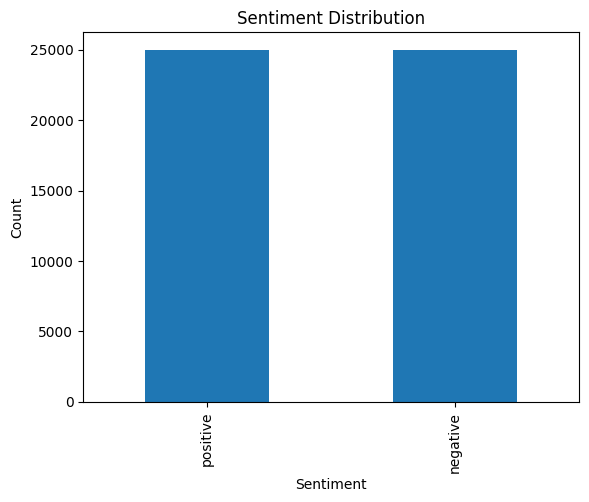

In [11]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [12]:
# Stage 4: Data Cleaning
# Checking for missing values and duplicate reviews.

In [13]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(418)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.shape

(49582, 2)

In [17]:
# Stage 5: Feature Extraction using TF-IDF
# Converting review text into numerical vectors.
# Machine learning algorithms cannot understand raw text. TF-IDF converts text into numerical form while preserving important words.

In [18]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = vectorizer.fit_transform(
    df['review']
)

In [19]:
# Stage 6: Similarity Matrix
# Calculating similarity between reviews.
# Reviews with similar content may represent similar movie preferences.

In [20]:
similarity_matrix = cosine_similarity(
    tfidf_matrix
)

In [21]:
# Stage 7: Create Recommendation Function
# Creating a function that finds the most similar reviews.

In [22]:
def recommend_reviews(index, n=5):

    similarity_scores = list(
        enumerate(similarity_matrix[index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = similarity_scores[1:n+1]

    return recommendations

In [23]:
# Stage 8: Generate Recommendations
# Generating recommendations for a sample review.

In [24]:
recommend_reviews(0)

[(34262, np.float64(0.48085134756722947)),
 (2348, np.float64(0.47477730963764864)),
 (31671, np.float64(0.4313284064219314)),
 (2617, np.float64(0.4256990485108698)),
 (33357, np.float64(0.42451298998225867))]

In [25]:
# Stage 9: Display Recommended Reviews
# Displaying the actual recommended reviews.

In [26]:
recommendations = recommend_reviews(0)

for i in recommendations:
    print(df.iloc[i[0]]['review'][:300])
    print("-"*50)

One of the best TV shows out there, if not the best one. Why? Simple: it has guts to show us real life in prison, without any clichés and predictable twists. This is not Prison Break or any other show, actually comparing to Oz the show Sopranos look like story for children's. Profanity, cursing, sho
--------------------------------------------------
In relative terms having watched a lot of disgustingly bad tele Tom Fontana & Levinson are geniuses for creating & delivering In this writer's book the greatest ever TV show. Oz was treated horribly In this country, the finale went out well gone 3 In the morning, before that It was strictly consider
--------------------------------------------------
Oz, is one of the most mind-blowing and addictive TV experiences ever.<br /><br />Having caught pieces of this on SBS, I was at first skeptical, however, having finished now the 4th season, I sadly know that that this brilliant show is approaching its end, (6 seasons), and yet I still can't get 

In [27]:
# Findings
# 1. The dataset contained approximately 50,000 movie reviews with positive and negative sentiment labels.
# 2. Duplicate reviews were removed to improve recommendation quality.
# 3. TF-IDF Vectorization was used to convert textual reviews into numerical representations.
# 4. Cosine Similarity was used to measure similarity between reviews.
# 5. The recommendation system successfully identified reviews with similar content and sentiment patterns.
# 6. Since user ratings were not available, a content-based recommendation approach was implemented instead of collaborative filtering.

In [28]:
# Conclusion
# Built a content-based movie recommendation system using movie review data.
# Applied TF-IDF Vectorization to convert text reviews into numerical features.
# Used Cosine Similarity to identify reviews with similar content.
# Generated recommendations based on review similarity.
# Demonstrated how recommendation systems can be developed even when user-rating data is unavailable.